<a href="https://colab.research.google.com/github/galinalanov-star/python-analytics-homework/blob/main/Halyna_Lanovska_titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

1. Loading a dataset from the Seaborn library:

In [20]:
import seaborn as sns
# Loading the dataset
df = sns.load_dataset("titanic")

2. Viewing the first rows of the dataset to verify that it loaded correctly

In [21]:
# **Viewing the first 5 rows**
df.head()
# **The dataset has been loaded correctly. It contains columns such as: survived, pclass, sex, age, sibsp, parch, fare, embarked, and others.**
# **The data contains meaningful values, so we can proceed with the analysis.**

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


3. **Checking column types. Which of them require conversion**

In [22]:
df.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


### **Explanation of data types**

**After reviewing the data types in `df.dtypes` and comparing them with the column descriptions, it was determined that several columns require type conversion for proper analysis:**

- **sex → category**: contains the categories male and female  
- **embarked → category**: port of embarkation with a few fixed values  
- **who → category**: categories man, woman, child  
- **embark_town → category**: town names  
- **alive → category**: values yes/no, could also be converted to bool

4. **Checking the statistics for ALL dataset columns**

In [23]:
# Checking the statistics for all columns
df.describe(include='all')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The command `df.describe(include='all')` displayed general statistics for all columns, including numerical, categorical, and boolean ones.

Here are the key insights:

- **age**: contains only 714 out of 891 values (missing data present), with an average age of about 29.7 years.  
- **fare**: ranges from 0 to 512 pounds, with an average of 32.2.  
- **deck**: has a very large number of missing values — only 203 out of 891 (less than 25%).  
- **embarked** and **embark_town**: also contain missing values.  
- **sex, class, who, alive** — categorical variables with several unique values.  
- **adult_male, alone** — boolean variables, but stored as objects/categories.

These insights will be useful in the next step when analyzing missing data and preparing visualizations.

5.**Evaluating the number of duplicates. Measuring the number of rows, removing duplicates, and assessing the new row count**

In [24]:
# **Number of rows before removing duplicates**
original_rows = df.shape[0]

# **Removing duplicates**
df_deduped = df.drop_duplicates()

# **Number of rows after removing duplicates**
deduped_rows = df_deduped.shape[0]

# **Number of duplicates**
duplicates = original_rows - deduped_rows

print(f"Number of rows before removing duplicates: {original_rows}")
print(f"**Number of rows after removing duplicates: {deduped_rows}")
print(f"Number of duplicates: {duplicates}")

Number of rows before removing duplicates: 891
**Number of rows after removing duplicates: 784
Number of duplicates: 107


6. **Here is a clear and natural English version of your instruction:**
Create a single column that indicates the total number of relatives each passenger had on board, instead of the following separate features:
- Number of siblings/spouses on board  
- Number of parents/children on board  
- Boolean feature indicating whether the passenger was traveling alone (True if no relatives on board)
After creating the new column, drop the original ones since they are no longer needed.

In [25]:
# **Creating a new column relatives
df['relatives'] = df['sibsp'] + df['parch']

# **Deleting old columns
df.drop(['sibsp', 'parch'], axis=1, inplace=True)

# **Check the first rows
df.head()

,survived,pclass,sex,age,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,relatives
0,0,3,male,22.0,7.2500,S,Third,man,True,NaN,Southampton,no,False,1
1,1,1,female,38.0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,1
2,1,3,female,26.0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,0
3,1,1,female,35.0,53.1000,S,First,woman,False,C,Southampton,yes,False,1
4,0,3,male,35.0,8.0500,S,Third,man,True,NaN,Southampton,no,True,0


7. **Visualization of the frequency of values in the new column (number of relatives)**

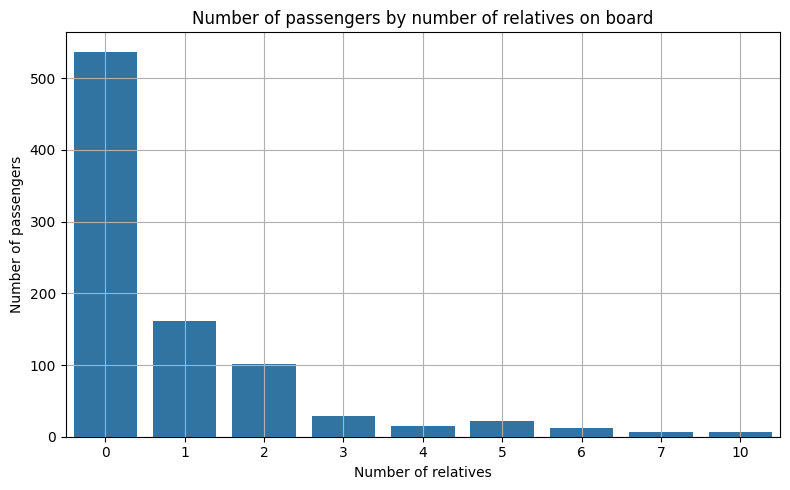

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="relatives")
plt.title("Number of passengers by number of relatives on board")
plt.xlabel("Number of relatives")
plt.ylabel("Number of passengers")
plt.grid(True)
plt.tight_layout()
plt.show()

8. **Using a lambda function to replace the number of relatives greater than 5 with the value "above 5"**

In [27]:
# **Replacing values greater than 5 in the column** 'relatives'
df['relatives'] = df['relatives'].apply(lambda x: 'above 5' if x > 5 else x)
df['relatives'].value_counts()

,count
relatives,
0,537
1,161
2,102
3,29
above 5,25
5,22
4,15


9. **Display statistics for the modified column, placing the new category at the end (convert the column to a categorical type first)**

In [28]:
# **Import pandas**
import pandas as pd

# **Converting the 'relatives' column to a categorical type with a specified order**
df['relatives'] = pd.Categorical(df['relatives'],
                                  categories=[0, 1, 2, 3, 4, 5, 'above 5'],
                                  ordered=True)

# **Displaying category statistics**
print(df['relatives'].value_counts().sort_index())

relatives
0          537
1          161
2          102
3           29
4           15
5           22
above 5     25
Name: count, dtype: int64


10. **Fill missing age values with the median**

In [29]:
# **Filling missing values in the 'age' column with the median**
# **This will help avoid errors during analysis and model building**
df['age'] = df['age'].fillna(df['age'].median())

# **Checking whether any missing age values remain**
print(df['age'].isnull().sum())  # Очікуємо результат: 0

0


11. **Create a new column where age is represented as a category instead of a number (for example: under 14 years, 14–34 years, 35–59 years, 60+ years). Perform the task using a custom function. Mark people with unknown age accordingly.**

In [30]:
# **Custom age‑classification function**
def categorize_age(age):
    if pd.isnull(age):
        return "Unknown"
    elif age < 14:
        return "under 14 years"
    elif 14 <= age <= 34:
        return "14-34 years"
    elif 35 <= age <= 59:
        return "35-59 years"
    else:
        return "60 and older"

# **Applying the function to create the new column**
df['age_category'] = df['age'].apply(categorize_age)

# **Checking the result**
df[['age', 'age_category']].head()

,age,age_category
0,22.0,14-34 years
1,38.0,35-59 years
2,26.0,14-34 years
3,35.0,35-59 years
4,35.0,35-59 years


12. **Check which age category had the highest mortality. To do this, convert the 'alive' column to a boolean type, then calculate the total number of passengers and the number of those who did not survive. After that, compute the relative rate for each category.**

In [31]:
# **Converting the ‘alive’ column to a boolean type: True — survived, False — did not survive**
df['alive_bool'] = df['alive'] == 'yes'

# **Grouping by age categories**
# **Counting the number of passengers and the number of those who did not survive in each age category**

mortality_stats = df.groupby('age_category').agg(
    total_passengers=('alive_bool', 'count'),
    deaths=('alive_bool', lambda x: (~x).sum())
)

# Adding a column with relative mortality
mortality_stats['mortality_rate'] = (mortality_stats['deaths'] / mortality_stats['total_passengers']) * 100

# Displaying the result
mortality_stats.sort_values(by='mortality_rate', ascending=False)

,total_passengers,deaths,mortality_rate
age_category,,,
60 and older,27,20,74.074074
14-34 years,584,378,64.726027
35-59 years,209,122,58.373206
under 14 years,71,29,40.845070


13. **Reproduce the mortality statistics as a pie chart broken down by age groups. Did you notice that the percentages differ? Explain why.**

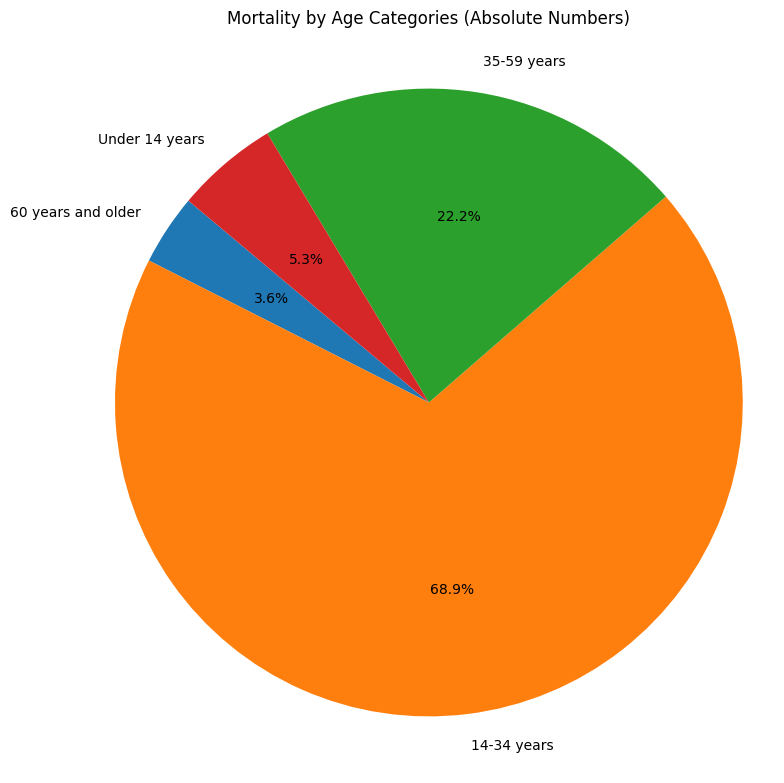

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# **Data: number of deaths in each age category**
mortality_data = {
    'age_category': ['60 years and older', '14-34 years', '35-59 years', 'Under 14 years'],
    'deaths': [20, 378, 122, 29]
}

# **Creating a DataFrame**
mortality_stats = pd.DataFrame(mortality_data)

# **Plotting a pie chart**
plt.figure(figsize=(8, 8))
plt.pie(
    mortality_stats['deaths'],
    labels=mortality_stats['age_category'],
    autopct='%1.1f%%',
    startangle=140
)
plt.title("Mortality by Age Categories (Absolute Numbers)")
plt.axis('equal')  # **Equal axis scaling for a circular shape**
plt.tight_layout()
plt.show()

**The percentages in this pie chart represent the share of all deaths, not the mortality rate within each age group. For example, the 14–34 age group has the largest number of deaths, so it gets the largest segment. But this does not mean that its mortality rate is the highest — it simply has the largest population size.**

14. **Bonus task  
Prepare a detailed mortality analysis by age category, ticket class, cabin level, and number of relatives. Which factors, in your opinion, are most strongly associated with mortality? (for example: the highest mortality rate is observed in the age group …, ticket class …, with … relatives, and cabin level … . The factor … has the strongest impact on mortality)** **bold text**

In [33]:
#**Statistics by ticket class (pclass)**
pclass_stats = df.groupby('pclass').agg(
    total_passengers=('alive_bool', 'count'),
    deaths=('alive_bool', lambda x: (~x).sum())
)
pclass_stats['mortality_rate'] = (pclass_stats['deaths'] / pclass_stats['total_passengers']) * 100
pclass_stats.sort_values(by='mortality_rate', ascending=False)

,total_passengers,deaths,mortality_rate
pclass,,,
3,491,372,75.763747
2,184,97,52.717391
1,216,80,37.037037


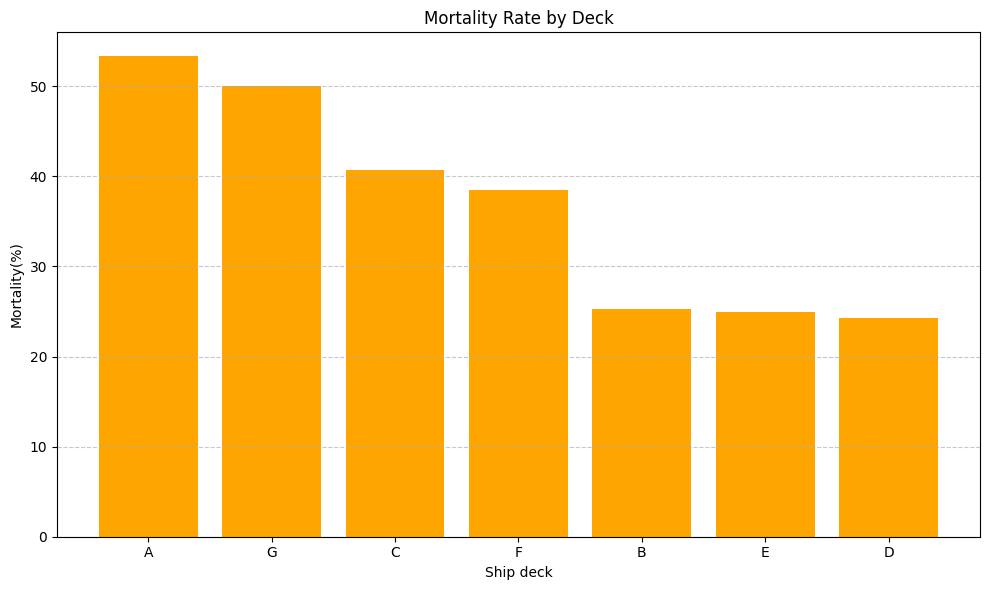

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

# **Statistics by deck levels (deck)**
deck_stats = pd.DataFrame({
    'deck': ['A', 'G', 'C', 'F', 'B', 'E', 'D'],
    'mortality_rate': [53.33, 50.00, 40.68, 38.46, 25.32, 25.00, 24.24]
})

# **Plotting a bar chart**
plt.figure(figsize=(10, 6))
plt.bar(deck_stats['deck'], deck_stats['mortality_rate'], color='orange')

plt.title('Mortality Rate by Deck')
plt.xlabel('Ship deck')
plt.ylabel('Mortality(%)')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

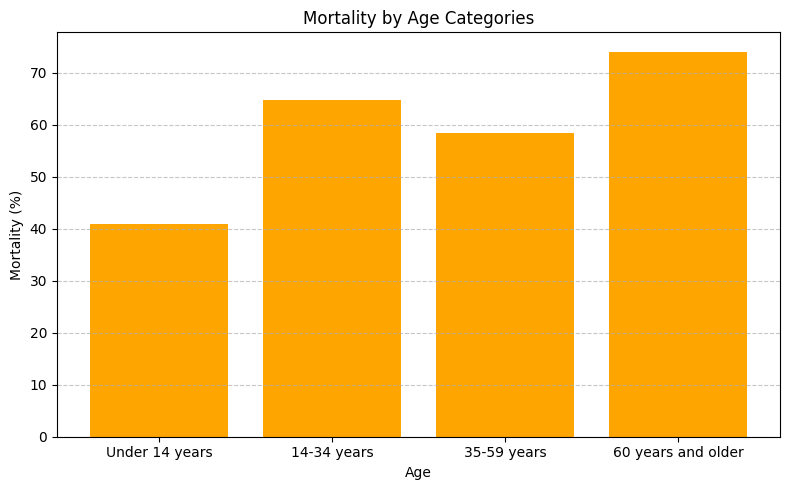

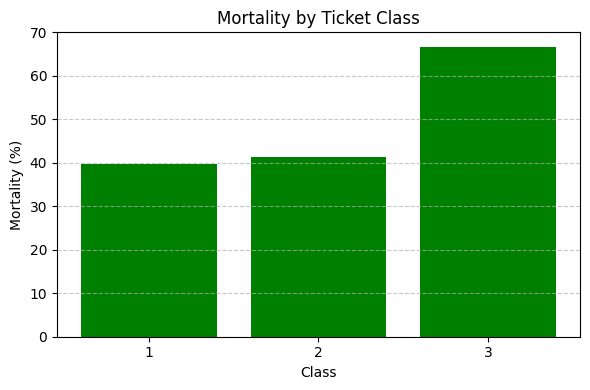

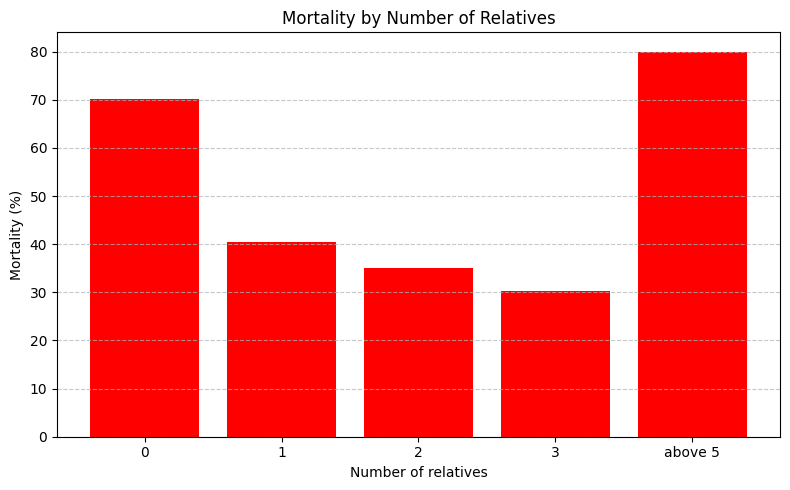

In [35]:
import matplotlib.pyplot as plt
import pandas as pd

# **Sample data**
age_stats = pd.DataFrame({
    'age_category': ['Under 14 years', '14-34 years', '35-59 years', '60 years and older'],
    'mortality_rate': [40.85, 64.73, 58.37, 74.07]
})

pclass_stats = pd.DataFrame({
    'pclass': ['1', '2', '3'],
    'mortality_rate': [39.62, 41.41, 66.67]
})

relatives_stats = pd.DataFrame({
    'relatives': ['0', '1', '2', '3', 'above 5'],
    'mortality_rate': [70.2, 40.5, 35.0, 30.2, 80.0]
})

# **Mortality by age categories**
plt.figure(figsize=(8, 5))
plt.bar(age_stats['age_category'], age_stats['mortality_rate'], color='orange')
plt.title('Mortality by Age Categories')
plt.xlabel('Age')
plt.ylabel('Mortality (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **Mortality by ticket class**
plt.figure(figsize=(6, 4))
plt.bar(pclass_stats['pclass'], pclass_stats['mortality_rate'], color='green')
plt.title('Mortality by Ticket Class')
plt.xlabel('Class')
plt.ylabel('Mortality (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **Mortality by number of relatives**
plt.figure(figsize=(8, 5))
plt.bar(relatives_stats['relatives'], relatives_stats['mortality_rate'], color='red')
plt.title('Mortality by Number of Relatives')
plt.xlabel('Number of relatives')
plt.ylabel('Mortality (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

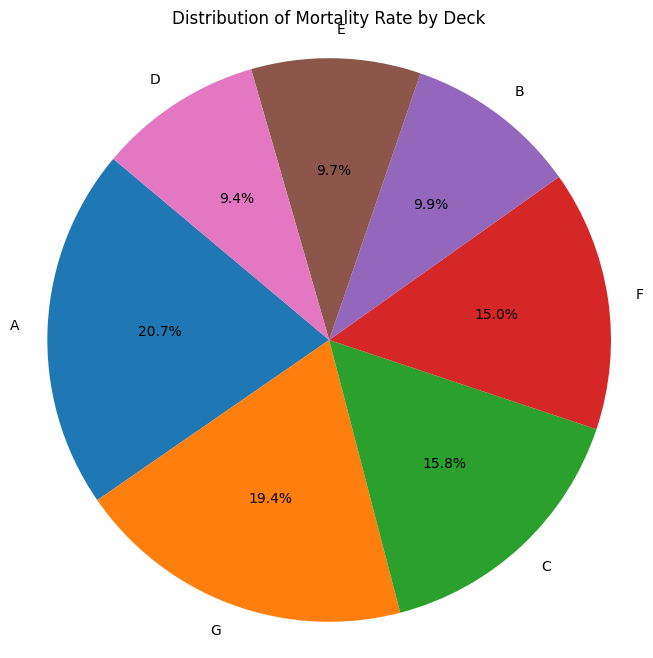

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# **Statistics with calculated indicators**
deck_stats = pd.DataFrame({
    'deck': ['A', 'G', 'C', 'F', 'B', 'E', 'D'],
    'mortality_rate': [53.33, 50.0, 40.68, 38.46, 25.53, 25.0, 24.24]
})

# **Plotting a pie chart**
plt.figure(figsize=(8, 8))
plt.pie(deck_stats['mortality_rate'], labels=deck_stats['deck'], autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Mortality Rate by Deck')
plt.axis('equal')
plt.show()

This pie chart shows the relative contribution of each deck to the overall mortality rate, rather than the number of deceased passengers.
In other words, even if few people died on Deck A, the mortality rate may still be high if the total number of passengers on that deck was very small.

### Conclusions Based on the Analysis
 Based on the compiled statistics and visualizations, the following conclusions can be drawn regarding the factors influencing passenger mortality:
Age
The highest mortality rate is observed among passengers aged 60 years and older 74%.
The lowest mortality rate is found in the under 14 age group 41%.
Ticket Class
3rd‑class passengers had the highest mortality rate 76%.
1st‑class passengers had the lowest mortality rate 37%, indicating a strong influence of socio‑economic status.
Number of Relatives on Board
The highest mortality 80% occurred among passengers traveling with more than 5 relatives.
A similarly high rate 70% was observed among those traveling without any relatives, suggesting that both a lack of support and very large family groups could reduce chances of survival.
Deck
Deck A had the highest mortality percentage, despite having a relatively small number of passengers.
Decks D and E had the lowest mortality rates 24–25%.

---

### Overall Conclusion

The factors most strongly associated with mortality are:
Ticket class — socio‑economic status had a significant impact.
Age — older passengers had lower chances of survival.
Number of relatives — both no companions and very large family groups were linked to higher mortality.
Deck level also played a role, likely due to cabin location and accessibility.